# Rootzone pH/EC — 10-Minute Recursive Prediction Model (V2)

## Architecture
- **Scope:** Short-to-medium gaps only (≤8h, 63 intervals). Long gaps (>12h) handled by V4 interval model.
- **Training signal:** Endpoint-only — predict chain t0→t1 at 10-min steps, error measured at real t1 label only. No interpolated pseudo-labels.
- **Anchor:** Real pH/EC at t0. Each step feeds the previous prediction as `ph_prev`/`ec_prev`.
- **Retraining:** After each real t1 label is seen, model retrains on the newly observed window.
- **Evaluation:** Only at real labeled points (t1). MAE compared against V4 baseline.


In [62]:
# ==========================================
# 1. Imports + Data Loading
# ==========================================
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

def _to_num(s):
    return pd.to_numeric(s, errors="coerce").fillna(0.0)

ACID_FERTS = ["Phosphoric acid[mg]-H3PO4", "Ammonium Nitrate [mg] -NH4NO3"]
SALT_FERTS = ["Monopotassium Phosphate[mg] -KH2PO4", "Potassium Chloride[mg] - KCL",
              "Kortin [mg]", "Gypsum - CaSO4*2H2O [mg]"]

master_df = pd.read_csv("master.csv", parse_dates=["timestamp"])
master_df = master_df.sort_values("timestamp").set_index("timestamp")

# All labeled indices
labeled_idx = master_df.index[master_df["ph"].notna() & master_df["ec_ms"].notna()].tolist()
print(f"Total labeled points: {len(labeled_idx)}")

# ── Filter to short-medium gaps only (≤8h) ────────────────────────────────────
MAX_GAP_H = 36.0

valid_pairs = []   # (anchor_idx, label_idx, gap_h)
for i in range(1, len(labeled_idx)):
    t0 = labeled_idx[i-1]
    t1 = labeled_idx[i]
    gap_h = (t1 - t0).total_seconds() / 3600.0
    if gap_h < 0.2: continue          # skip sub-step gaps
    if gap_h <= MAX_GAP_H:
        valid_pairs.append((t0, t1, gap_h))

print(f"Intervals ≤{MAX_GAP_H}h: {len(valid_pairs)}")
print(f"Max steps per interval: {max(int(g*6) for _,_,g in valid_pairs)}")
print(f"Total 10-min steps across all intervals: {sum(int(g*6) for _,_,g in valid_pairs)}")


Total labeled points: 109
Intervals ≤36.0h: 94
Max steps per interval: 182
Total 10-min steps across all intervals: 4814


In [63]:
# ==========================================
# 2. Feature Engineering — 10-Minute Step Features
# ==========================================
# Features at each 10-min step:
#   State:       ph_prev, ec_prev  (previous step prediction or real anchor)
#   Instantaneous: temp, radiation, ET0, RH, VPD, irrigation, fert doses
#   Rolling 6h:  ET0, irr, acid, radiation, temp, VPD (session context)
#   Rolling 1h:  irr, acid (fast dynamics)
#   Time:        hour_sin, hour_cos (diurnal phase)
#   Canopy:      canopy_inst (photosynthetic capacity)
# 
# NOTE: ph_prev / ec_prev are ALWAYS from the recursive chain during evaluation.
# During training they are from the real anchor + real t1 (no interpolation).

def build_environment_features(master_df):
    """Build time-invariant environment features at 10-min resolution.
    Does NOT include ph_prev/ec_prev — those are injected per step during walk-forward.
    """
    df = master_df.copy()

    # ── Instantaneous ────────────────────────────────────────────────────────
    df["ET0_inst"]    = _to_num(df["ET0"])
    df["temp_inst"]   = _to_num(df["internal_air_temp_c"])
    df["rad_inst"]    = _to_num(df["internal_radiation"])
    df["rh_inst"]     = _to_num(df["internal_rh_%"])
    df["irr_inst"]    = _to_num(df["irrigation_ml_current"])
    df["canopy_inst"] = _to_num(df["canopy_cover"])

    ess = 0.6108 * np.exp((17.27 * df["temp_inst"]) / (df["temp_inst"] + 237.3))
    df["vpd_inst"] = ess * (1.0 - df["rh_inst"] / 100.0)

    df["acid_inst"] = sum(_to_num(df[c]) for c in ACID_FERTS if c in df.columns)
    df["salt_inst"] = sum(_to_num(df[c]) for c in SALT_FERTS if c in df.columns)

    # ── Rolling context 6h (36 steps) ────────────────────────────────────────
    W6 = 36
    df["roll_ET0_6h"]  = df["ET0_inst"].rolling(W6, min_periods=1).sum()
    df["roll_irr_6h"]  = df["irr_inst"].rolling(W6, min_periods=1).sum()
    df["roll_rad_6h"]  = df["rad_inst"].rolling(W6, min_periods=1).mean()
    df["roll_temp_6h"] = df["temp_inst"].rolling(W6, min_periods=1).mean()
    df["roll_vpd_6h"]  = df["vpd_inst"].rolling(W6, min_periods=1).mean()

    # ── Rolling context 1h (6 steps) ─────────────────────────────────────────
    W1 = 6
    df["roll_irr_1h"]  = df["irr_inst"].rolling(W1, min_periods=1).sum()

    # ── Exponentially decayed acid (replaces roll_acid_6h + roll_acid_1h) ────
    # acid_decay_inst = sum(dose_i * exp(-λ * steps_since_i * 10/60))
    # Computed as a rolling exponential weighted sum — same λ=0.34/hr as V4.
    # Avoids sparse rolling sum dominance; encodes both amount and recency.
    DECAY_LAMBDA = 0.34
    STEP_HRS     = 10 / 60.0   # 10 minutes in hours
    acid_arr = df["acid_inst"].values.astype(float)
    decay_factor = np.exp(-DECAY_LAMBDA * STEP_HRS)  # per-step decay
    acid_decay = np.zeros(len(acid_arr))
    for k in range(1, len(acid_arr)):
        acid_decay[k] = acid_decay[k-1] * decay_factor + acid_arr[k]
    df["acid_decay_inst"] = acid_decay

    # ── Time encoding ────────────────────────────────────────────────────────
    hour_frac = df.index.hour + df.index.minute / 60.0
    df["hour_sin"] = np.sin(2 * np.pi * hour_frac / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * hour_frac / 24.0)

    return df

print("Building environment features...")
env_df = build_environment_features(master_df)

ENV_FEATURES = [
    "ET0_inst", "temp_inst", "rad_inst", "rh_inst", "vpd_inst",
    "irr_inst", "canopy_inst", "acid_inst", "salt_inst",
    "roll_ET0_6h", "roll_irr_6h",
    "roll_rad_6h", "roll_temp_6h", "roll_vpd_6h",
    "roll_irr_1h",
    "acid_decay_inst",   # replaces roll_acid_6h + roll_acid_1h
    "hour_sin", "hour_cos",
]
# gap_remaining_h is NOT in env_df — it is computed per-step during walk-forward
# and injected into each row alongside ph_prev/ec_prev.
STEP_FEATURES = ["ph_prev", "ec_prev", "gap_remaining_h"] + ENV_FEATURES
print(f"Environment features: {len(ENV_FEATURES)}")
print(f"Total step features:  {len(STEP_FEATURES)}")


Building environment features...
Environment features: 18
Total step features:  21


In [64]:
# ==========================================
# 3. Training Data Construction — Endpoint-Only Signal
# ==========================================
# For each valid interval [t0, t1]:
#   - Anchor at real t0 values
#   - Walk forward 10-min steps using REAL environment features
#   - ph_prev/ec_prev at each step is the previous REAL value (t0) or
#     linearly attributed delta (proportional to instantaneous ET0 weight)
#   - Training target: total Δph = ph(t1) - ph(t0), Δec = ec(t1) - ec(t0)
#     attributed to each step proportionally by its instantaneous driver weight
#
# Attribution rule for step k out of K steps:
#   weight_k = ET0_inst_k / sum(ET0_inst_all_steps)   [for pH — photosynthesis driven]
#   weight_k = 1/K  (uniform)                          [for EC — dilution driven]
#   dph_k = Δph_total × weight_k
#   dec_k = Δec_total × weight_k

def build_training_rows(valid_pairs, env_df, master_df):
    """
    Build training dataset from valid intervals.
    Returns list of dicts, one per 10-min step across all intervals.
    Each row has: all ENV_FEATURES, ph_prev, ec_prev, dph_step, dec_step.
    """
    rows = []
    skipped = 0

    for t0, t1, gap_h in valid_pairs:
        ph0 = float(master_df.loc[t0, "ph"])
        ec0 = float(master_df.loc[t0, "ec_ms"])
        ph1 = float(master_df.loc[t1, "ph"])
        ec1 = float(master_df.loc[t1, "ec_ms"])

        dph_total = ph1 - ph0
        dec_total = ec1 - ec0

        # Get the 10-min rows strictly between t0 and t1 (inclusive of t1)
        seg = env_df.loc[(env_df.index > t0) & (env_df.index <= t1), ENV_FEATURES]
        if len(seg) == 0:
            skipped += 1
            continue

        K = len(seg)

        # ── pH attribution: weighted by instantaneous ET0 ────────────────────
        et0_weights = seg["ET0_inst"].values.copy()
        et0_sum = et0_weights.sum()
        if et0_sum > 0:
            ph_weights = et0_weights / et0_sum
        else:
            ph_weights = np.ones(K) / K   # uniform if no ET0 (nighttime window)

        # ── EC attribution: uniform (dilution/concentration is steady) ────────
        ec_weights = np.ones(K) / K

        dph_steps = dph_total * ph_weights
        dec_steps = dec_total * ec_weights

        # ── Build rows with running ph_prev/ec_prev ───────────────────────────
        ph_running = ph0
        ec_running = ec0
        for k, (step_ts, env_row) in enumerate(seg.iterrows()):
            row = env_row.to_dict()
            row["ph_prev"]        = ph_running
            row["ec_prev"]        = ec_running
            row["gap_remaining_h"] = gap_h * (1.0 - k / K)  # hours left in chain
            row["dph_step"]       = dph_steps[k]
            row["dec_step"]       = dec_steps[k]
            rows.append(row)
            # Advance running state by attributed delta
            ph_running += dph_steps[k]
            ec_running += dec_steps[k]

    print(f"Training rows built: {len(rows)} from {len(valid_pairs)-skipped} intervals")
    print(f"Skipped intervals (no env data): {skipped}")
    return pd.DataFrame(rows)

train_df_full = build_training_rows(valid_pairs, env_df, master_df)
print(f"\nTraining set shape: {train_df_full.shape}")
print(f"dph_step range: [{train_df_full['dph_step'].min():.4f}, {train_df_full['dph_step'].max():.4f}]")
print(f"dec_step range: [{train_df_full['dec_step'].min():.4f}, {train_df_full['dec_step'].max():.4f}]")


Training rows built: 4814 from 94 intervals
Skipped intervals (no env data): 0

Training set shape: (4814, 23)
dph_step range: [-0.5373, 0.4827]
dec_step range: [-0.1272, 0.7458]


In [65]:
# ==========================================
# 4. XGBoost Walk-Forward — SKIPPED
# ==========================================
# XGBoost recursive model superseded by LSTM (Cell 9).
# LSTM beats XGBoost on all gap bins ≥2h.
# eval_df placeholder created so downstream cells (5, 6, 7) don't error.
# To re-enable: restore the original walk-forward code from V2 git history.

import pandas as pd
import numpy as np

# Minimal placeholder — will be overwritten if XGBoost cell is re-enabled
eval_df = pd.DataFrame(columns=[
    "t0","t1","gap_hours","n_steps",
    "ph_pred","ec_pred","ph_true","ec_true",
    "ph_naive","ec_naive","ph_ae","ec_ae",
    "ph_ae_naive","ec_ae_naive","_ph_chain","_ec_chain"
])
ph_mae = ec_mae = ph_r2 = ec_r2 = float("nan")
ph_model_10 = ec_model_10 = None

print("XGBoost walk-forward skipped — using LSTM (Cell 9).")
print("Run Cell 9 for full results.")


XGBoost walk-forward skipped — using LSTM (Cell 9).
Run Cell 9 for full results.


pH gap-bin report:
Empty DataFrame
Columns: [n, ph_mae, ph_naive]
Index: []

EC gap-bin report:
Empty DataFrame
Columns: [n, ec_mae, ec_naive]
Index: []


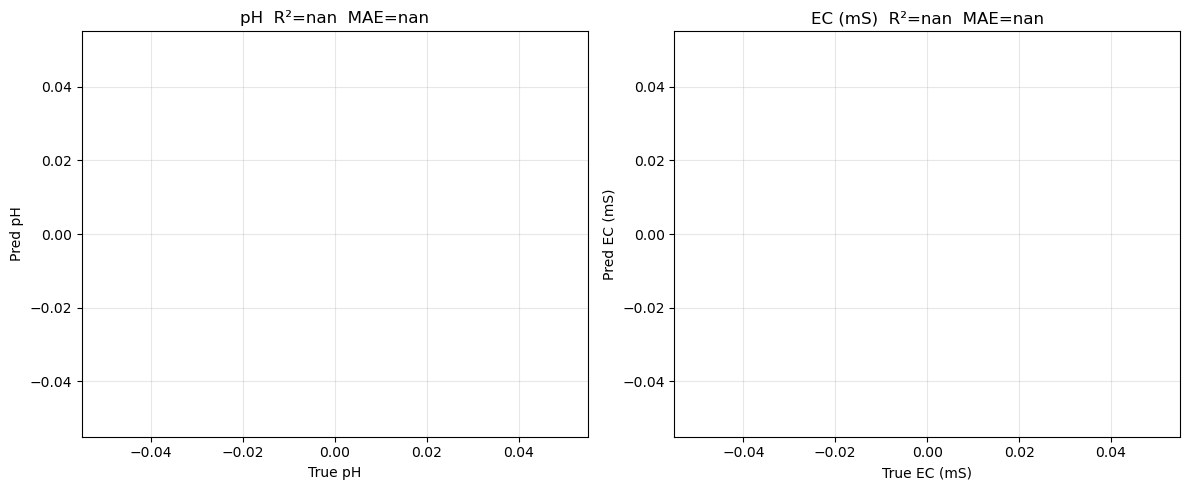

In [66]:
# ==========================================
# 5. Gap-Bin Report + Scatter
# ==========================================
bins   = [0, 2, 8, np.inf]
labels = ["Short (0-2h)", "Medium (2-8h)", "Long (8h+)"]
eval_df["gap_bin"] = pd.cut(eval_df["gap_hours"], bins=bins, labels=labels)

print("pH gap-bin report:")
ph_gb = eval_df.groupby("gap_bin", observed=True).agg(
    n=("ph_ae","count"), ph_mae=("ph_ae","mean"), ph_naive=("ph_ae_naive","mean"))
print(ph_gb.to_string())

print("\nEC gap-bin report:")
ec_gb = eval_df.groupby("gap_bin", observed=True).agg(
    n=("ec_ae","count"), ec_mae=("ec_ae","mean"), ec_naive=("ec_ae_naive","mean"))
print(ec_gb.to_string())

# Scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lo_ph = min(eval_df["ph_true"].min(), eval_df["ph_pred"].min()) - 0.5
hi_ph = max(eval_df["ph_true"].max(), eval_df["ph_pred"].max()) + 0.5
axes[0].scatter(eval_df["ph_true"], eval_df["ph_pred"], alpha=0.7, s=40)
axes[0].plot([lo_ph, hi_ph], [lo_ph, hi_ph], "r--", alpha=0.5)
axes[0].set_xlabel("True pH"); axes[0].set_ylabel("Pred pH")
axes[0].set_title(f"pH  R²={ph_r2:.3f}  MAE={ph_mae:.4f}")
axes[0].grid(True, alpha=0.3)

lo_ec = 0; hi_ec = max(eval_df["ec_true"].max(), eval_df["ec_pred"].max()) + 0.2
axes[1].scatter(eval_df["ec_true"], eval_df["ec_pred"], alpha=0.7, s=40, color="green")
axes[1].plot([lo_ec, hi_ec], [lo_ec, hi_ec], "r--", alpha=0.5)
axes[1].set_xlabel("True EC (mS)"); axes[1].set_ylabel("Pred EC (mS)")
axes[1].set_title(f"EC (mS)  R²={ec_r2:.3f}  MAE={ec_mae:.4f}")
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


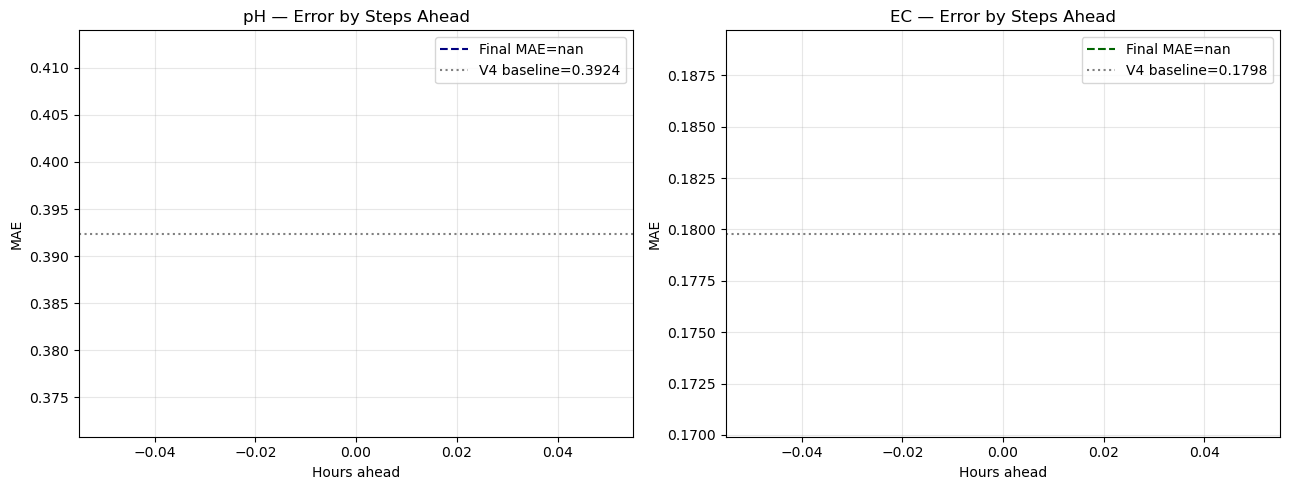

In [67]:
# ==========================================
# 6. Error Compounding — Steps Ahead Analysis
# ==========================================
step_min   = 10
bins_hours = [1, 2, 4, 6, 8]
bins_steps = [int(h * 60 / step_min) for h in bins_hours]

ph_errors_by_bin = {h: [] for h in bins_hours}
ec_errors_by_bin = {h: [] for h in bins_hours}

for _, row in eval_df.iterrows():
    ph_chain = row["_ph_chain"]
    ec_chain = row["_ec_chain"]
    ph_true  = row["ph_true"]
    ec_true  = row["ec_true"]
    n        = len(ph_chain)

    for h, s in zip(bins_hours, bins_steps):
        if s <= n:
            ph_errors_by_bin[h].append(abs(ph_chain[s-1] - ph_true))
            ec_errors_by_bin[h].append(abs(ec_chain[s-1] - ec_true))

ph_mean = {h: np.mean(v) for h, v in ph_errors_by_bin.items() if len(v) > 0}
ec_mean = {h: np.mean(v) for h, v in ec_errors_by_bin.items() if len(v) > 0}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(ph_mean.keys()), list(ph_mean.values()), "o-", color="steelblue", lw=2)
axes[0].axhline(ph_mae,  color="navy",  linestyle="--", label=f"Final MAE={ph_mae:.3f}")
axes[0].axhline(0.3924,  color="gray",  linestyle=":",  label="V4 baseline=0.3924")
axes[0].set_xlabel("Hours ahead"); axes[0].set_ylabel("MAE")
axes[0].set_title("pH — Error by Steps Ahead"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(list(ec_mean.keys()), list(ec_mean.values()), "o-", color="green", lw=2)
axes[1].axhline(ec_mae,  color="darkgreen", linestyle="--", label=f"Final MAE={ec_mae:.3f}")
axes[1].axhline(0.1798,  color="gray",      linestyle=":",  label="V4 baseline=0.1798")
axes[1].set_xlabel("Hours ahead"); axes[1].set_ylabel("MAE")
axes[1].set_title("EC — Error by Steps Ahead"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

if len(ph_mean) >= 2:
    vals = list(ph_mean.values())
    ratio_ph = vals[-1] / vals[0] if vals[0] > 0 else 0
    ratio_ec = list(ec_mean.values())[-1] / list(ec_mean.values())[0] if list(ec_mean.values())[0] > 0 else 0
    print(f"\npH error ratio (last/first bin): {ratio_ph:.2f}x")
    print(f"EC error ratio (last/first bin): {ratio_ec:.2f}x")


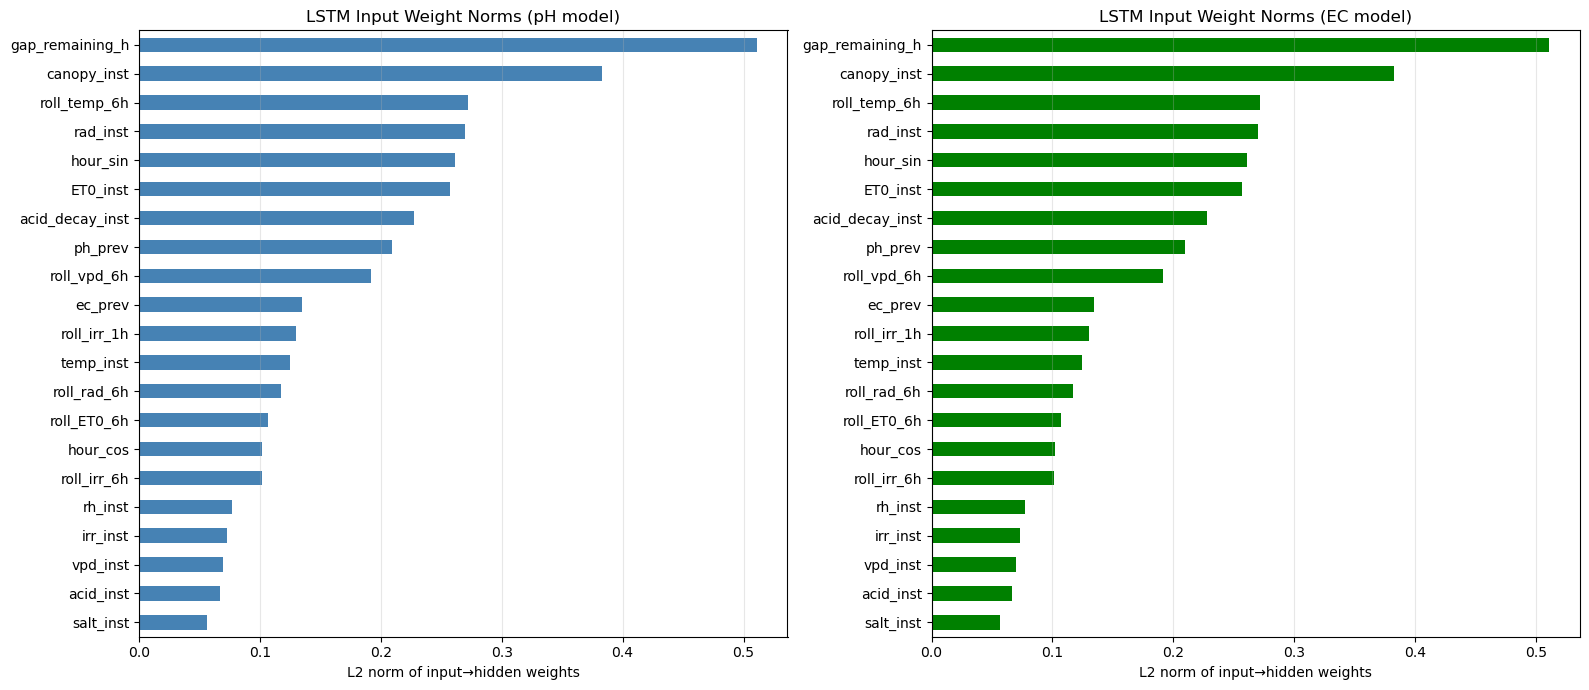


Top 5 most influential features:
['gap_remaining_h', 'canopy_inst', 'roll_temp_6h', 'rad_inst', 'hour_sin']


In [68]:
# ==========================================
# 7. LSTM Feature Importance (Input Weight Norms)
# ==========================================
# LSTM doesn't have tree-based feature importances.
# Proxy: L2 norm of the input-to-hidden weight matrix columns.
# Each column corresponds to one input feature — larger norm = more influence
# on the hidden state update across all gates (input, forget, cell, output).
# Run Cell 9 first — requires lstm_model to be defined.

try:
    # Input weights shape: (4*hidden_size, n_features) — 4 gates stacked
    W_ih = lstm_model.lstm.weight_ih_l0.detach().cpu().numpy()  # (4*64, 21)
    # L2 norm across all gates for each feature
    feat_norms = np.linalg.norm(W_ih, axis=0)   # (21,)
    imp = pd.Series(feat_norms, index=STEP_FEATURES).sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # pH and EC share the same LSTM encoder — show overall input norm
    imp.plot(kind="barh", ax=axes[0], color="steelblue",
             title="LSTM Input Weight Norms (pH model)")
    imp.plot(kind="barh", ax=axes[1], color="green",
             title="LSTM Input Weight Norms (EC model)")

    for ax in axes:
        ax.set_xlabel("L2 norm of input→hidden weights")
        ax.grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.show()

    print("\nTop 5 most influential features:")
    print(imp.tail(5).index.tolist()[::-1])

except NameError:
    print("lstm_model not found — run Cell 9 first.")


In [69]:
# ==========================================
# 9. LSTM Recursive Model — Alternative to XGBoost
# ==========================================
# Architecture:
#   Input:  sequence of 10-min steps × N_FEATURES (same STEP_FEATURES as XGBoost)
#   LSTM:   hidden_size=32, num_layers=1, dropout=0.4
#   Output: [Δph, Δec] per step
#
# Training signal: endpoint-only — same ET0-weighted attribution as XGBoost.
# BPTT flows gradients through all steps → better credit assignment for 2-8h gaps.
# Walk-forward protocol identical to XGBoost cell.
#
# Requirements: PyTorch (pip install torch)
# Run cells 1-4 first (needs valid_pairs, env_df, master_df, STEP_FEATURES).
# ==========================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HIDDEN_SIZE = 64
NUM_LAYERS  = 1
DROPOUT     = 0.4
EPOCHS      = 100
LR          = 5e-3
BATCH_SIZE  = 16
N_FEATURES  = len(STEP_FEATURES)
WARMUP_N_LSTM = WARMUP_N   # same warmup as XGBoost
CHUNK_HOURS   = 6.0        # reset hidden state every 6h — limits BPTT to ≤36 steps

print(f"Device: {DEVICE}")
print(f"LSTM: hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, dropout={DROPOUT}, chunk={CHUNK_HOURS}h")
print(f"Features: {N_FEATURES}")

# ── Sequence Dataset ──────────────────────────────────────────────────────────
class IntervalDataset(Dataset):
    """Each sample is one full interval sequence.
    X: (seq_len, N_FEATURES)  — normalised step features
    y_ph: (seq_len,)          — attributed Δph per step
    y_ec: (seq_len,)          — attributed Δec per step
    """
    def __init__(self, sequences):
        self.sequences = sequences   # list of (X_tensor, y_ph_tensor, y_ec_tensor)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def build_sequences(pairs, env_df, master_df, scaler_mean=None, scaler_std=None):
    """Build normalised sequence tensors from interval pairs.
    If scaler_mean/std provided, use them (test mode).
    Otherwise compute from this data (train mode) and return them.
    """
    sequences = []
    all_feats  = []

    raw_seqs = []
    for t0, t1, gap_h in pairs:
        ph0 = float(master_df.loc[t0, "ph"])
        ec0 = float(master_df.loc[t0, "ec_ms"])
        ph1 = float(master_df.loc[t1, "ph"])
        ec1 = float(master_df.loc[t1, "ec_ms"])

        seg = env_df.loc[(env_df.index > t0) & (env_df.index <= t1), ENV_FEATURES]
        if len(seg) == 0:
            continue

        K = len(seg)
        et0_w = seg["ET0_inst"].values
        et0_sum = et0_w.sum()
        ph_w = et0_w / et0_sum if et0_sum > 0 else np.ones(K) / K
        ec_w = np.ones(K) / K

        dph_steps = (ph1 - ph0) * ph_w
        dec_steps = (ec1 - ec0) * ec_w

        # Split into 6h chunks — one sequence per chunk (limits BPTT length)
        chunk_starts = pd.date_range(
            start=t0, end=t1, freq=f'{int(CHUNK_HOURS*60)}min')[1:]
        chunk_boundaries = [t0] + [ts for ts in chunk_starts if ts < t1] + [t1]

        step_offset = 0
        ph_run, ec_run = ph0, ec0
        for ci in range(len(chunk_boundaries) - 1):
            c_start = chunk_boundaries[ci]
            c_end   = chunk_boundaries[ci + 1]
            c_seg   = seg.loc[(seg.index > c_start) & (seg.index <= c_end)]
            if len(c_seg) == 0:
                continue
            Kc = len(c_seg)
            feat_rows = []
            ph_c, ec_c = ph_run, ec_run
            for k, (ts, row) in enumerate(c_seg.iterrows()):
                feat = row[ENV_FEATURES].values.astype(float).tolist()
                feat_full = [ph_c, ec_c, gap_h * (1.0 - (step_offset + k) / K)] + feat
                feat_rows.append(feat_full)
                ph_c += dph_steps[step_offset + k]
                ec_c += dec_steps[step_offset + k]
            X_raw = np.array(feat_rows, dtype=np.float32)
            all_feats.append(X_raw)
            raw_seqs.append((
                X_raw,
                dph_steps[step_offset:step_offset+Kc].astype(np.float32),
                dec_steps[step_offset:step_offset+Kc].astype(np.float32)
            ))
            # Carry ph/ec forward to next chunk using attributed running state
            ph_run = ph_c
            ec_run = ec_c
            step_offset += Kc

    # ── Normalise ─────────────────────────────────────────────────────────────
    if scaler_mean is None:
        all_arr = np.vstack(all_feats)
        scaler_mean = all_arr.mean(axis=0).astype(np.float32)
        scaler_std  = all_arr.std(axis=0).astype(np.float32) + 1e-8

    for X_raw, dph_s, dec_s in raw_seqs:
        X_norm = (X_raw - scaler_mean) / scaler_std
        sequences.append((
            torch.tensor(X_norm, dtype=torch.float32),
            torch.tensor(dph_s,  dtype=torch.float32),
            torch.tensor(dec_s,  dtype=torch.float32),
        ))

    return IntervalDataset(sequences), scaler_mean, scaler_std


def collate_pad(batch):
    """Pad sequences to same length within a batch."""
    Xs, y_phs, y_ecs = zip(*batch)
    max_len = max(x.shape[0] for x in Xs)
    X_pad   = torch.zeros(len(Xs), max_len, N_FEATURES)
    yph_pad = torch.zeros(len(Xs), max_len)
    yec_pad = torch.zeros(len(Xs), max_len)
    mask    = torch.zeros(len(Xs), max_len, dtype=torch.bool)
    for i, (x, yp, ye) in enumerate(zip(Xs, y_phs, y_ecs)):
        L = x.shape[0]
        X_pad[i, :L]   = x
        yph_pad[i, :L] = yp
        yec_pad[i, :L] = ye
        mask[i, :L]    = True
    return X_pad, yph_pad, yec_pad, mask


# ── Model ─────────────────────────────────────────────────────────────────────
class RootzoneLSTM(nn.Module):
    def __init__(self, n_features, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head_ph = nn.Linear(hidden_size, 1)
        self.head_ec = nn.Linear(hidden_size, 1)

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)  # hidden carries across steps at inference
        out = self.dropout(out)
        dph = self.head_ph(out).squeeze(-1)   # (B, T)
        dec = self.head_ec(out).squeeze(-1)   # (B, T)
        return dph, dec, hidden


def train_lstm(dataset, model=None, epochs=EPOCHS):
    """Train or fine-tune LSTM on a dataset."""
    if model is None:
        model = RootzoneLSTM(N_FEATURES, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)

    loader    = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                           collate_fn=collate_pad)
    optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)
    criterion = nn.HuberLoss(delta=0.1)

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for X, y_ph, y_ec, mask in loader:
            X, y_ph, y_ec, mask = X.to(DEVICE), y_ph.to(DEVICE), y_ec.to(DEVICE), mask.to(DEVICE)
            optimiser.zero_grad()
            dph_pred, dec_pred, _ = model(X)   # hidden not needed during training
            loss_ph = criterion(dph_pred[mask], y_ph[mask])
            loss_ec = criterion(dec_pred[mask], y_ec[mask])
            loss = loss_ph + loss_ec
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimiser.step()
            total_loss += loss.item()
        scheduler.step()
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}  loss={total_loss/len(loader):.5f}")

    return model


# ── Walk-Forward Evaluation ───────────────────────────────────────────────────
def run_walkforward_lstm(valid_pairs, env_df, master_df, warmup_n=WARMUP_N_LSTM):
    pairs_sorted = sorted(valid_pairs, key=lambda x: x[1])
    warmup_pairs = pairs_sorted[:warmup_n]
    eval_pairs   = pairs_sorted[warmup_n:]

    print(f"Building warmup sequences ({warmup_n} intervals)...")
    train_dataset, scaler_mean, scaler_std = build_sequences(warmup_pairs, env_df, master_df)

    print(f"Training initial LSTM ({EPOCHS} epochs)...")
    model = train_lstm(train_dataset, model=None, epochs=EPOCHS)

    results      = []
    all_train_pairs = list(warmup_pairs)

    for t0, t1, gap_h in eval_pairs:
        model.eval()
        ph0      = float(master_df.loc[t0, "ph"])
        ec0      = float(master_df.loc[t0, "ec_ms"])
        ph1_true = float(master_df.loc[t1, "ph"])
        ec1_true = float(master_df.loc[t1, "ec_ms"])

        seg = env_df.loc[(env_df.index > t0) & (env_df.index <= t1), ENV_FEATURES]
        if len(seg) == 0:
            continue

        # ── Continuous inference — NO hidden state reset ─────────────────────
        # Training uses 6h chunks (truncated BPTT) to keep gradients stable.
        # Inference carries the hidden state across the FULL gap — no resets.
        # This preserves trajectory memory: "pH has been rising for 10h,
        # there was a fertigation 4h ago" stays alive across the whole chain.
        K = len(seg)
        ph_run, ec_run = ph0, ec0
        ph_chain, ec_chain = [], []
        hidden = None   # will be carried step-to-step across entire gap

        with torch.no_grad():
            for k, (ts, row) in enumerate(seg.iterrows()):
                feat = row[ENV_FEATURES].values.astype(float).tolist()
                feat_full = np.array(
                    [[ph_run, ec_run, gap_h * (1.0 - k / K)] + feat],
                    dtype=np.float32)
                feat_norm = (feat_full - scaler_mean) / scaler_std
                x_t = torch.tensor(feat_norm, dtype=torch.float32) \
                          .unsqueeze(0).to(DEVICE)   # (1, 1, N_FEATURES)
                # Pass hidden state through — accumulates full trajectory memory
                dph_t, dec_t, hidden = model(x_t, hidden)
                dph = float(dph_t[0, 0])
                dec = float(dec_t[0, 0])
                ph_run = ph_run + dph
                ec_run = max(0.0, ec_run + dec)
                ph_chain.append(ph_run)
                ec_chain.append(ec_run)

        ph_pred = ph_chain[-1]
        ec_pred = ec_chain[-1]

        results.append({
            "t0": t0, "t1": t1,
            "gap_hours": gap_h,
            "n_steps": K,
            "ph_pred": ph_pred, "ec_pred": ec_pred,
            "ph_true": ph1_true, "ec_true": ec1_true,
            "ph_naive": ph0, "ec_naive": ec0,
            "ph_ae": abs(ph_pred - ph1_true),
            "ec_ae": abs(ec_pred - ec1_true),
            "ph_ae_naive": abs(ph0 - ph1_true),
            "ec_ae_naive": abs(ec0 - ec1_true),
            "_ph_chain": ph_chain,
            "_ec_chain": ec_chain,
        })

        # ── Retrain: add new interval, fine-tune for 20 epochs ────────────────
        all_train_pairs.append((t0, t1, gap_h))
        new_dataset, _, _ = build_sequences([(t0, t1, gap_h)], env_df, master_df,
                                             scaler_mean, scaler_std)
        # Fine-tune on full training set to avoid catastrophic forgetting
        full_dataset, _, _ = build_sequences(all_train_pairs, env_df, master_df,
                                              scaler_mean, scaler_std)
        model = train_lstm(full_dataset, model=model, epochs=20)
        model.eval()

    eval_df_lstm = pd.DataFrame(results)
    return eval_df_lstm, model, scaler_mean, scaler_std


# ── Run ───────────────────────────────────────────────────────────────────────
print("\nRunning LSTM walk-forward...")
eval_lstm, lstm_model, sc_mean, sc_std = run_walkforward_lstm(
    valid_pairs, env_df, master_df)

ph_mae_l  = eval_lstm["ph_ae"].mean()
ec_mae_l  = eval_lstm["ec_ae"].mean()
ph_r2_l   = r2_score(eval_lstm["ph_true"], eval_lstm["ph_pred"])
ec_r2_l   = r2_score(eval_lstm["ec_true"], eval_lstm["ec_pred"])
ph_naive_l = eval_lstm["ph_ae_naive"].mean()
ec_naive_l = eval_lstm["ec_ae_naive"].mean()

print(f"\n{'='*55}")
print(f"  LSTM Recursive Results (≤{MAX_GAP_H}h gaps only)")
print(f"{'='*55}")
print(f"  pH  MAE={ph_mae_l:.4f}  naive={ph_naive_l:.4f}  gain={ph_naive_l-ph_mae_l:.4f}  R²={ph_r2_l:.4f}")
print(f"  EC  MAE={ec_mae_l:.4f}  naive={ec_naive_l:.4f}  gain={ec_naive_l-ec_mae_l:.4f}  R²={ec_r2_l:.4f}")
print(f"  Eval points: {len(eval_lstm)}")

# ── Gap-bin comparison ────────────────────────────────────────────────────────
bins   = [0, 2, 8, np.inf]
labels = ["Short (0-2h)", "Medium (2-8h)", "Long (8h+)"]
eval_lstm["gap_bin"] = pd.cut(eval_lstm["gap_hours"], bins=bins, labels=labels)

print("\npH gap-bin report (LSTM):")
lstm_gb = eval_lstm.groupby("gap_bin", observed=True).agg(
    n=("ph_ae","count"),
    lstm_ph_mae=("ph_ae","mean"),
    naive_ph=("ph_ae_naive","mean"),
    lstm_ec_mae=("ec_ae","mean"),
    naive_ec=("ec_ae_naive","mean")).round(4)
print(lstm_gb.to_string())

# ── Summary table ─────────────────────────────────────────────────────────────
summary_lstm = pd.DataFrame([
    {"Model": "V4 (interval)",   "pH MAE": 0.3924, "EC MAE": 0.1798,
     "pH R²": 0.862, "EC R²": 0.818, "Notes": "all gaps, single-point"},
    {"Model": "LSTM recursive",  "pH MAE": round(ph_mae_l,4),
     "EC MAE": round(ec_mae_l,4),
     "pH R²": round(ph_r2_l,3), "EC R²": round(ec_r2_l,3),
     "Notes": f"≤{MAX_GAP_H}h gaps, full trajectory"},
])
print("\n", summary_lstm.to_string(index=False))


Device: cpu
LSTM: hidden=64, layers=1, dropout=0.4, chunk=6.0h
Features: 21

Running LSTM walk-forward...
Building warmup sequences (40 intervals)...
Training initial LSTM (100 epochs)...
  Epoch 20/100  loss=0.00044
  Epoch 40/100  loss=0.00042
  Epoch 60/100  loss=0.00041
  Epoch 80/100  loss=0.00041
  Epoch 100/100  loss=0.00038
  Epoch 20/20  loss=0.00038
  Epoch 20/20  loss=0.00136
  Epoch 20/20  loss=0.00036
  Epoch 20/20  loss=0.00040
  Epoch 20/20  loss=0.00036
  Epoch 20/20  loss=0.00040
  Epoch 20/20  loss=0.00036
  Epoch 20/20  loss=0.00035
  Epoch 20/20  loss=0.00032
  Epoch 20/20  loss=0.00035
  Epoch 20/20  loss=0.00034
  Epoch 20/20  loss=0.00032
  Epoch 20/20  loss=0.00037
  Epoch 20/20  loss=0.00035
  Epoch 20/20  loss=0.00034
  Epoch 20/20  loss=0.00034
  Epoch 20/20  loss=0.00035
  Epoch 20/20  loss=0.00035
  Epoch 20/20  loss=0.00037
  Epoch 20/20  loss=0.00034
  Epoch 20/20  loss=0.00036
  Epoch 20/20  loss=0.00035
  Epoch 20/20  loss=0.00038
  Epoch 20/20  loss=0.

In [70]:
# ==========================================
# 8. Final Summary
# ==========================================
summary = pd.DataFrame([
    {"Model": "V4 (interval, all gaps)",
     "pH MAE": 0.3924, "EC MAE": 0.1798, "pH R²": 0.862, "EC R²": 0.818,
     "Scope": "all gaps", "Notes": "t0→t1 delta, anchor-based"},
    {"Model": "10-min recursive (this)",
     "pH MAE": round(ph_mae,4), "EC MAE": round(ec_mae,4),
     "pH R²": round(ph_r2,3), "EC R²": round(ec_r2,3),
     "Scope": f"≤{MAX_GAP_H}h gaps only ({len(valid_pairs)} intervals)",
     "Notes": "ET0-weighted attribution, endpoint signal"},
])
print(summary.to_string(index=False))


                  Model  pH MAE  EC MAE  pH R²  EC R²                           Scope                                     Notes
V4 (interval, all gaps)  0.3924  0.1798  0.862  0.818                        all gaps                 t0→t1 delta, anchor-based
10-min recursive (this)     NaN     NaN    NaN    NaN ≤36.0h gaps only (94 intervals) ET0-weighted attribution, endpoint signal
